(96453, 12)
           Humidity  Temperature (C)
count  96453.000000     96453.000000
mean       0.734899        11.932678
std        0.195473         9.551546
min        0.000000       -21.822222
25%        0.600000         4.688889
50%        0.780000        12.000000
75%        0.890000        18.838889
max        1.000000        39.905556


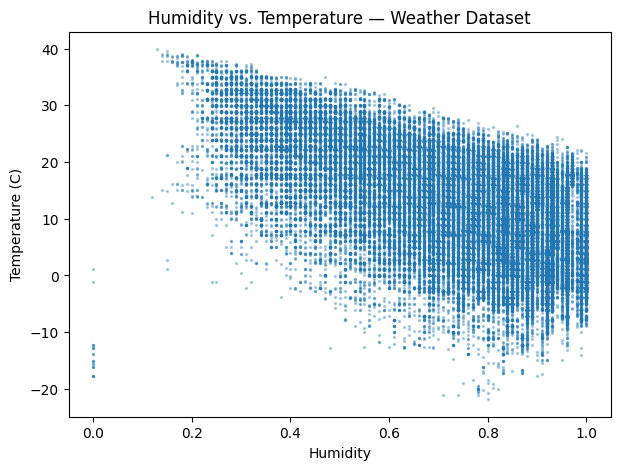

Learned model: Temperature = -30.9303 * Humidity + 34.66
Mean Absolute Error on test set: 6.01 degrees C


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Weather Dataset
DATA_PATH = "/kaggle/input/datasets/muthuj7/weather-dataset/weatherHistory.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df[["Humidity", "Temperature (C)"]].describe())

# Step 1: Visualise the data BEFORE modelling
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Humidity"],
    df["Temperature (C)"],
    s=2,
    alpha=0.3
)

plt.xlabel("Humidity")
plt.ylabel("Temperature (C)")
plt.title("Humidity vs. Temperature — Weather Dataset")

plt.show()

# Step 2: Prepare features (X) and labels (y)
X = df["Humidity"].to_numpy()
y = df["Temperature (C)"].to_numpy()

# Step 3: Split into training and test sets (80 / 20 split)
rng = np.random.default_rng(42)

indices = rng.permutation(len(X))

split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

# Step 4: Fit y = m*x + b using the least-squares method
def train_linear_regression(x_values, y_values):
    mean_x = x_values.mean()
    mean_y = y_values.mean()

    m = np.sum(
        (x_values - mean_x) * (y_values - mean_y)
    ) / np.sum(
        (x_values - mean_x) ** 2
    )

    b = mean_y - m * mean_x

    return m, b


m, b = train_linear_regression(X_train, y_train)

print(f"Learned model: Temperature = {m:.4f} * Humidity + {b:.2f}")

# Step 5: Evaluate on the held-out test set
predictions = m * X_test + b

mae = np.mean(np.abs(predictions - y_test))

print(f"Mean Absolute Error on test set: {mae:.2f} degrees C")